In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler

In [2]:
data = pd.read_csv(r"C:\Users\User\Downloads\boston_house_prices.csv", header = 1)
data = data.drop('B', axis = 1)
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
x = data.drop('MEDV',axis=1).values
y = data.MEDV.values

In [4]:
class MyLinearRegression:
    def __init__(self):
        self.cost = []
        self.a = False
        self.w, self.b = None, None
        self.wn, self.bn = None, None
    def normal_equation(self, x,y,return_intercept = True):
        if return_intercept:
            x = np.concatenate((np.ones((x.shape[0],1)),x),axis = 1)
        res = np.linalg.inv(x.T@x)@x.T@y
        self.wn = res[1:]
        self.bn = res[0]
        return res
    def gradient_descent(self, x, y, learning_rate = 0.01, iters = 500):
        y = y.reshape(-1,1)
        m,n = x.shape
        w = np.zeros((n,1))
        b = 0
        self.a = True
        self.cost = []
        for i in range(iters):
            y_predict = x@w + b
            error = y - y_predict 
            c = 1/(2*m) * np.sum((error)**2)
            self.cost.append(c)
            df_w = -1/m * (x.T@(error))
            df_b = -1/m * np.sum(error)
            w -= learning_rate*df_w
            b -= learning_rate*df_b
        self.w, self.b = w, b
        return w,b 
    def display_cost(self):
        if self.a:
            plt.plot(self.cost,'r')
            plt.xlabel('#Iterations')
            plt.ylabel('Cost function')
            plt.show()
        else:
            return 'No cost'
    def predict(self, x):
        return x@self.w + self.b

    def predict_normal(self, x):
        return x@self.wn + self.bn        



In [5]:
scaled_x = (x - x.mean(axis = 0))/x.std(axis=0)

Weights = [[-0.80279532]
 [ 0.58455106]
 [-0.4241544 ]
 [ 0.8203096 ]
 [-1.13623973]
 [ 3.071974  ]
 [-0.11730756]
 [-2.17178229]
 [ 0.79935849]
 [-0.63129363]
 [-1.81645239]
 [-3.59800616]], B = 22.384754902260084


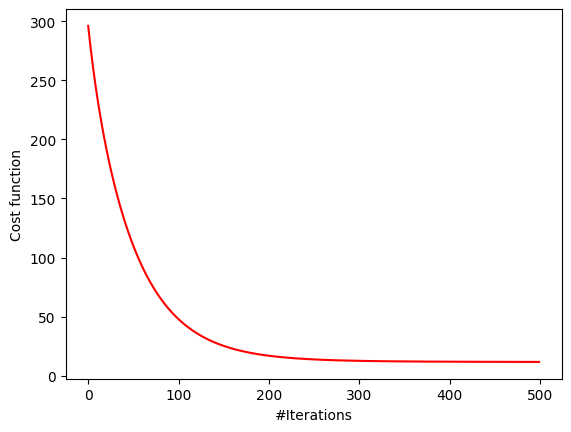

In [6]:
model = MyLinearRegression()
res = model.gradient_descent(scaled_x,y)
print(f"Weights = {res[0]}, B = {res[1]}")
model.display_cost()


In [7]:
print(model.predict(scaled_x[0]))

[30.51039493]


In [8]:
model.normal_equation(scaled_x, y)

array([22.53280632, -1.04309742,  1.09422031,  0.0923018 ,  0.72062826,
       -2.17148707,  2.56771612,  0.10153691, -3.13599165,  2.51742896,
       -2.13527146, -2.02770102, -3.93810517])

Gradient Descent
                Mse: 23.251319063040636
                Rmse: 4.821962159022055
                Mae: 3.307831054222611
                R^2: 0.7245742559931418
                
Normal Equation
                Mse: 22.429681439489926
                Rmse: 4.735998462783738
                Mae: 3.3563060455291462
                R^2: 0.7343070437613076
                
Scikit Learn
                Mse: 22.42968143948993
                Rmse: 4.735998462783738
                Mae: 3.3563060455291485
                R^2: 0.7343070437613076
                


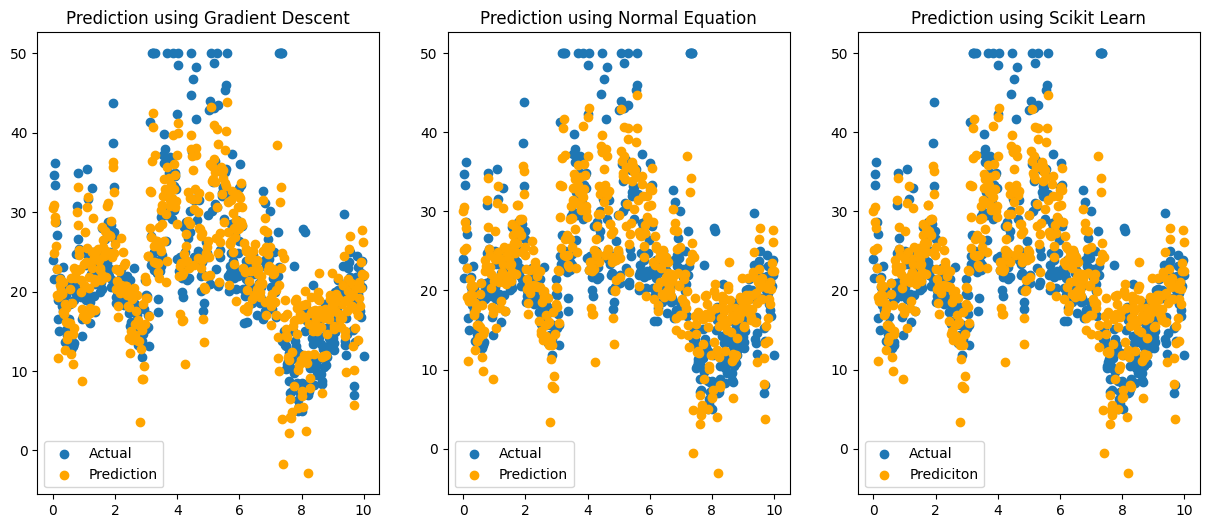

In [9]:
fig, ax = plt.subplots(1,3,figsize = (15,6))
ax[0].scatter(np.linspace(0,10,x.shape[0]),y)
ax[1].scatter(np.linspace(0,10,x.shape[0]),y)
ax[2].scatter(np.linspace(0,10,x.shape[0]),y)


l = LinearRegression()
l.fit(scaled_x, y)
pr_grad = model.predict(scaled_x)
pr_norm = model.predict_normal(scaled_x)
pr_sklearn = l.predict(scaled_x)

ax[0].scatter(np.linspace(0,10,x.shape[0]), pr_grad, color = 'orange')
ax[0].set_title('Prediction using Gradient Descent')
ax[0].legend(['Actual','Prediction'])

ax[1].scatter(np.linspace(0,10,x.shape[0]), pr_norm, color = 'orange')
ax[1].set_title('Prediction using Normal Equation')
ax[1].legend(['Actual','Prediction'])


ax[2].scatter(np.linspace(0,10,x.shape[0]), pr_sklearn, color = 'orange')
ax[2].set_title('Prediction using Scikit Learn')
ax[2].legend(['Actual','Prediciton'])

def metrics(name, pred, y):
    r = r2_score(y, pred)
    mse = mean_squared_error(y, pred)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mse)
    return f'''{name}
                Mse: {mse}
                Rmse: {rmse}
                Mae: {mae}
                R^2: {r}
                '''
print(metrics('Gradient Descent', pr_grad, y))
print(metrics('Normal Equation', pr_norm, y))
print(metrics('Scikit Learn', pr_sklearn, y))

In [41]:
def plotting_func(y_pr,y,title):
    plt.scatter(np.linspace(0,15,y.shape[0]),y, color = 'b')
    plt.scatter(np.linspace(0,15,y.shape[0]),y_pr, color = 'r', marker = 'x')
    plt.title(title)
    plt.legend(['Actual','Prediction'])
    plt.show()    

In [51]:
def run_model(name, model, x_train, y_train, x_test, y_test, plotting = False):
    model.fit(x_train, y_train)
    mse1 = mean_squared_error(y_test, model.predict(x_test))
    mse2 = mean_squared_error(y_train, model.predict(x_train))
    r1 = r2_score(y_test, model.predict(x_test))
    r2 = r2_score(y_train, model.predict(x_train))
    
    print(f'''{name} Train results
                Mse {mse2}
                R^2 {r2}''')
    print(f'''{name} Test results
                Mse {mse1}
                R^2 {r1}''')
    print(30*'-')
    if plotting:
        plotting_func(model.predict(x_train), y_train,'Prediction on training data')
        plotting_func(model.predict(x_test), y_test, 'Prediction on testing data')

Linear Train results
                Mse 21.423154929433046
                R^2 0.7340833053215706
Linear Test results
                Mse 25.568827171087037
                R^2 0.7200848561406525
------------------------------


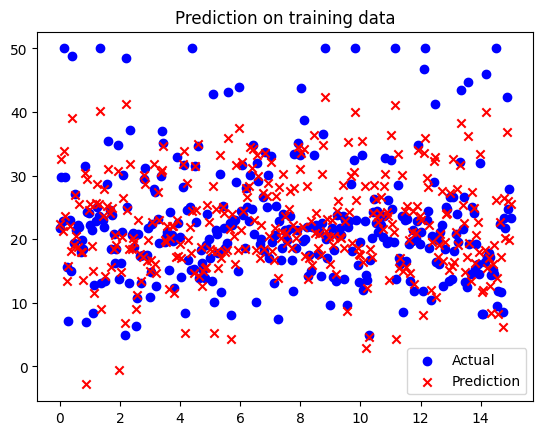

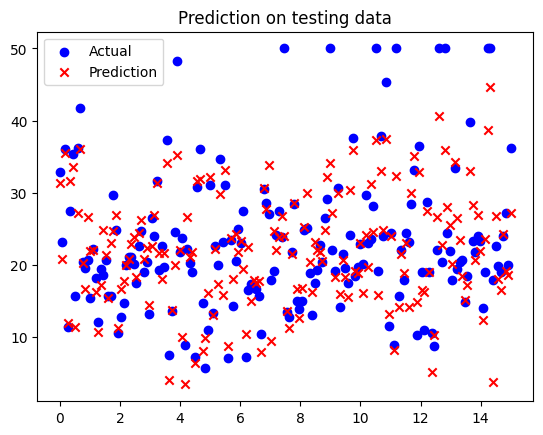

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.35)
sc = MinMaxScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
run_model('Linear', LinearRegression() , x_train, y_train, x_test, y_test, plotting = True)


Polynomial^2 Train results
                Mse 4.658277298480437
                R^2 0.9421787450920394
Polynomial^2 Test results
                Mse 14.968544345549361
                R^2 0.83613162168864
------------------------------


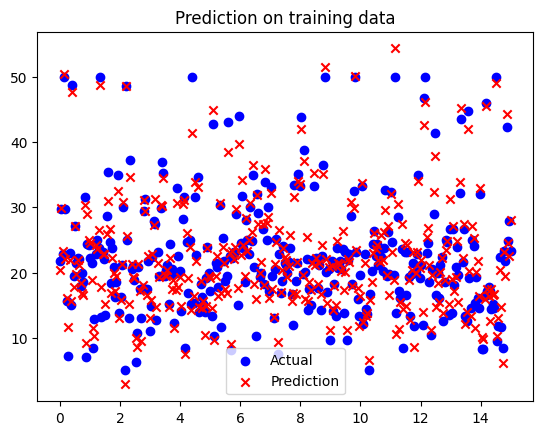

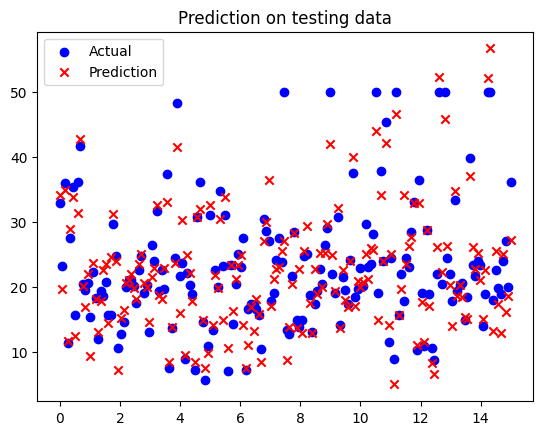

Polynomial^3 Train results
                Mse 4.5348290965190054e-20
                R^2 1.0
Polynomial^3 Test results
                Mse 1115048.8818189981
                R^2 -12206.015444083818
------------------------------


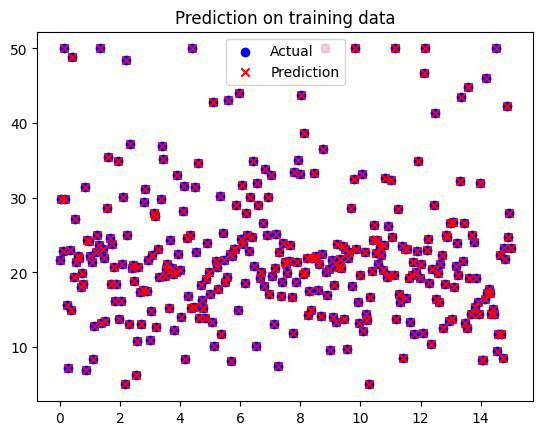

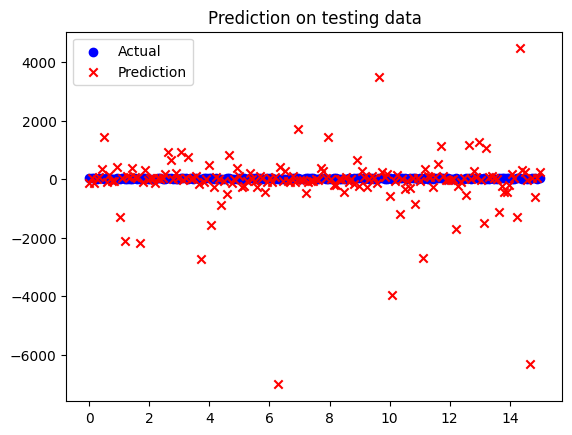

Polynomial^4 Train results
                Mse 6.4120060348782855e-24
                R^2 1.0
Polynomial^4 Test results
                Mse 3009.686665873001
                R^2 -31.948592847545328
------------------------------


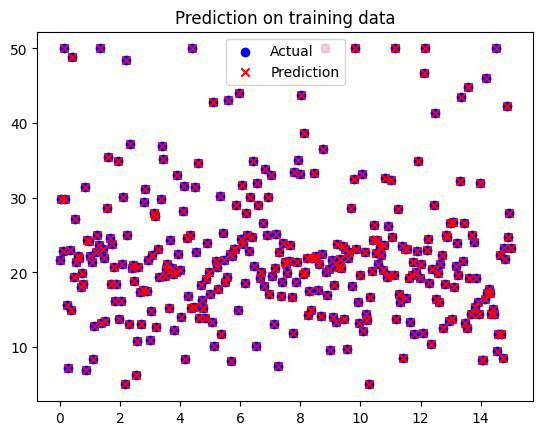

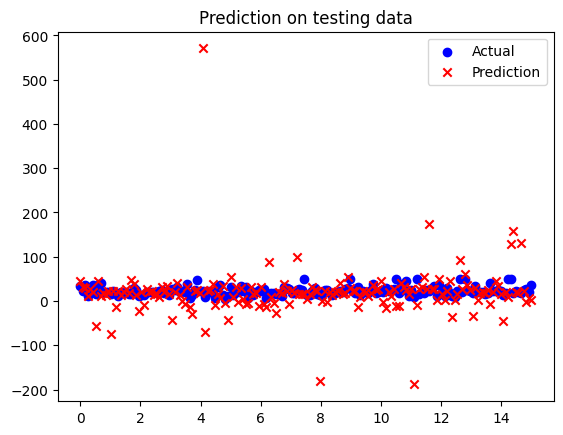

Polynomial^5 Train results
                Mse 6.09258889004914e-25
                R^2 1.0
Polynomial^5 Test results
                Mse 1642.3923595312517
                R^2 -16.980116589451626
------------------------------


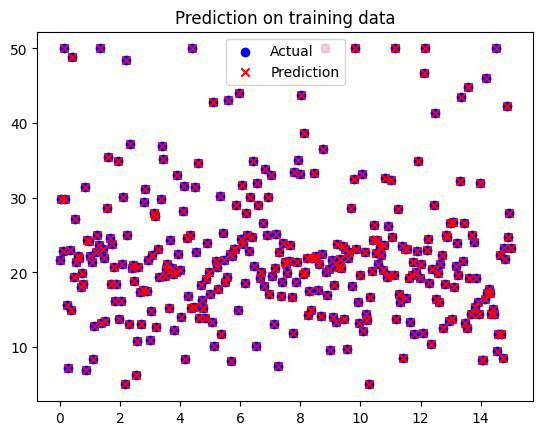

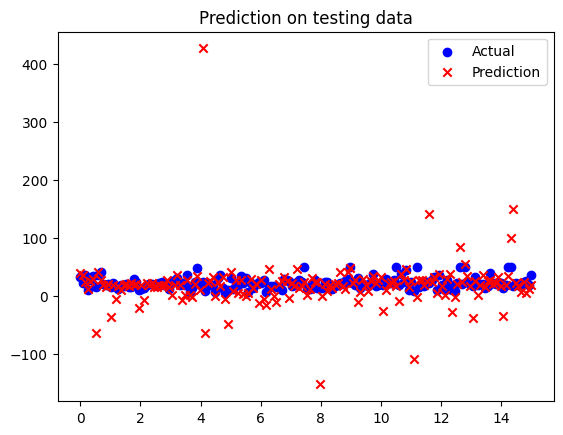

Polynomial^6 Train results
                Mse 2.912136839228796e-25
                R^2 1.0
Polynomial^6 Test results
                Mse 1044.3820676215994
                R^2 -10.433389366916131
------------------------------


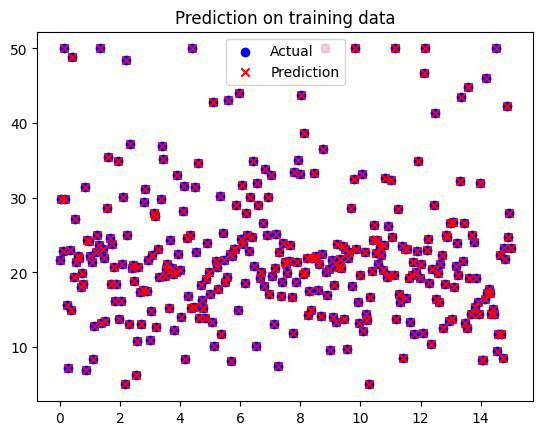

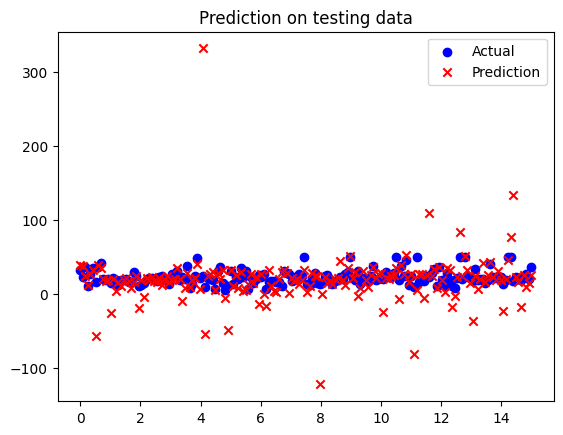

Polynomial^7 Train results
                Mse 3.4948706987767433e-25
                R^2 1.0
Polynomial^7 Test results
                Mse 689.8669566717684
                R^2 -6.552329527220103
------------------------------


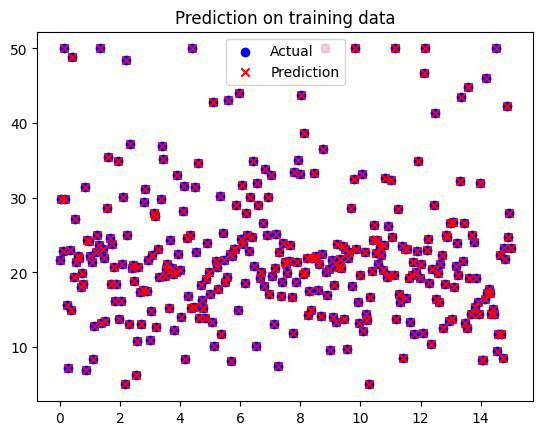

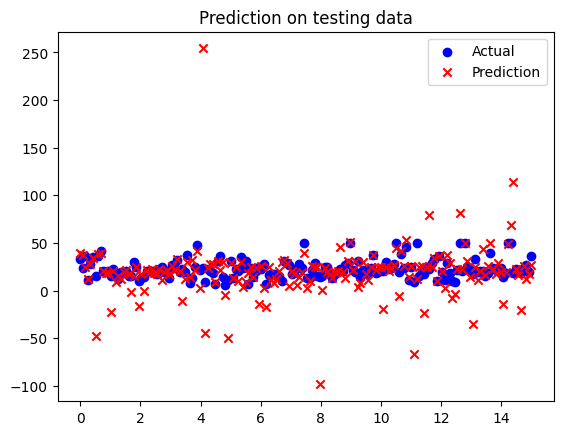

In [56]:
for i in range(2,8):
    poly = PolynomialFeatures(degree = i)
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)
    run_model(f'Polynomial^{i}', LinearRegression(), x_train_poly, y_train, x_test_poly, y_test, plotting = True)

Ridge Train results
                Mse 21.841026179037957
                R^2 0.7288964436356004
Ridge Test results
                Mse 27.20319607483262
                R^2 0.702192576461571
------------------------------


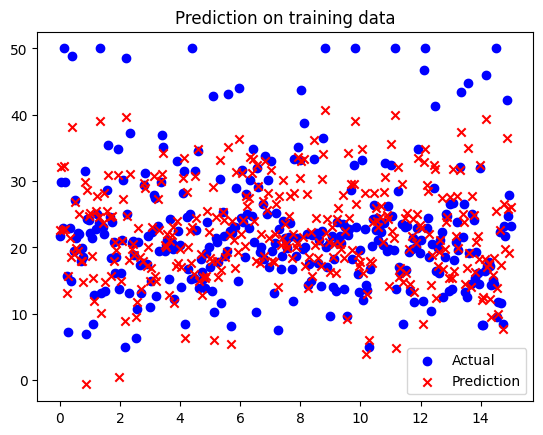

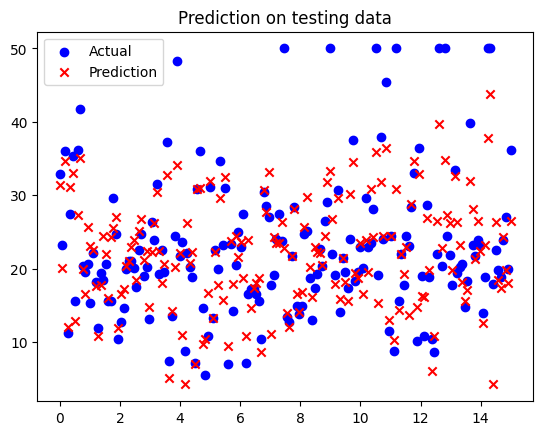

Lasso Train results
                Mse 61.175296708982785
                R^2 0.24065653493103822
Lasso Test results
                Mse 71.33502070937122
                R^2 0.21905872136941407
------------------------------


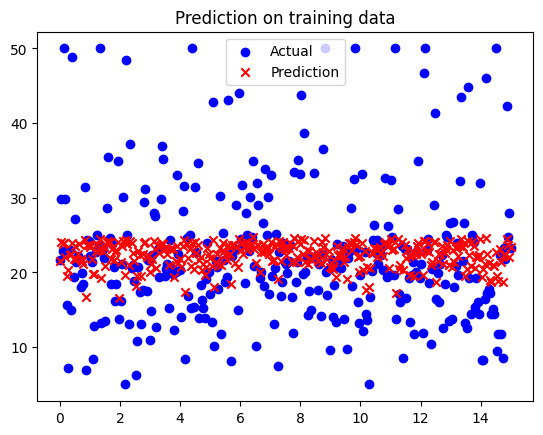

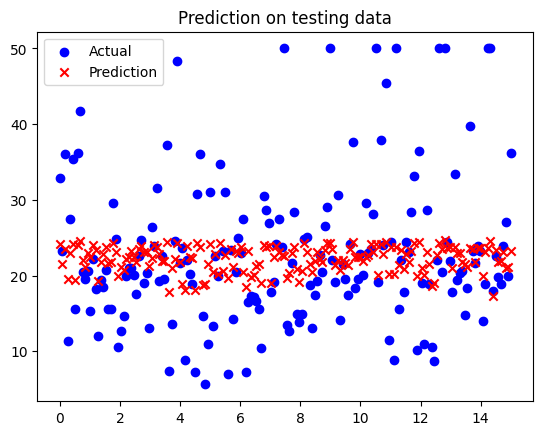

In [57]:
run_model('Ridge', Ridge(alpha = 1.0) , x_train, y_train, x_test, y_test, plotting = True)
run_model('Lasso', Lasso(alpha = 1.0) , x_train, y_train, x_test, y_test, plotting = True)
